<a href="https://colab.research.google.com/github/dzuokumor/group-22-formative-3/blob/main/bayesian_probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Problem Statement
we want to know:

“Given a positive COVID-19 test result, what is the probability the person actually has COVID-19?”

Key facts about our test and population:

Prevalence (prior): 2% of people are infected.

Sensitivity (true positive rate): 90% (test correctly flags 90% of infected).

Specificity (true negative rate): 95% (test correctly clears 95% of uninfected).


2. Define Probabilities

Let:

𝐷 = event “person has COVID-19”

¬D = event “person does not have COVID-19”

Pos = event “test is positive”

Then:

𝑃
(
𝐷
)
=
0.02
,
(prior)

𝑃
(
¬
𝐷
)
=
1
−
𝑃
(
𝐷
)
=
0.98
,

𝑃
(
Pos
∣
𝐷
)
=
0.90
,
(sensitivity)

𝑃
(
Pos
∣
¬
𝐷
)
=
1
−
0.95
=
0.05
,
(false positive rate)


3. Step-by-Step Bayesian Update

3.1 Compute Marginal
𝑃
(
Pos
)
P(Pos)

By the law of total probability:

𝑃
(
Pos
)  
=P(Pos∣D)P(D)+P(Pos∣¬D)P(¬D)
=0.90×0.02+0.05×0.98
=0.018+0.049=0.067
​


3.2 Compute Posterior
𝑃
(
𝐷
∣
Pos
)
P(D∣Pos)

Apply Bayes’ theorem:

𝑃
(
𝐷
∣
Pos
)
=
𝑃
(
Pos
∣
𝐷
)
𝑃
(
𝐷
) over
𝑃
(
Pos
)
=
0.90
×
0.02 over
0.067
≈0.2687(26.9%)
​


4. Python Implementation

In [2]:
# Given probabilities
P_D = 0.02                # Prior: prevalence
P_not_D = 0.98

sens = 0.90               # P(Pos | D)
false_pos = 0.05          # P(Pos | not D)

# 1) Marginal P(Pos)
P_Pos = sens * P_D + false_pos * P_not_D

# 2) Posterior P(D | Pos)
P_D_given_Pos = sens * P_D / P_Pos

# Display results
print(f"Prior P(D)               = {P_D:.4f}")
print(f"Likelihood P(Pos|D)      = {sens:.4f}")
print(f"Marginal P(Pos)          = {P_Pos:.4f}")
print(f"Posterior P(D|Pos)       = {P_D_given_Pos:.4f}")
print(f"--> {P_D_given_Pos*100:.1f}% chance of COVID-19 given a positive test")


Prior P(D)               = 0.0200
Likelihood P(Pos|D)      = 0.9000
Marginal P(Pos)          = 0.0670
Posterior P(D|Pos)       = 0.2687
--> 26.9% chance of COVID-19 given a positive test


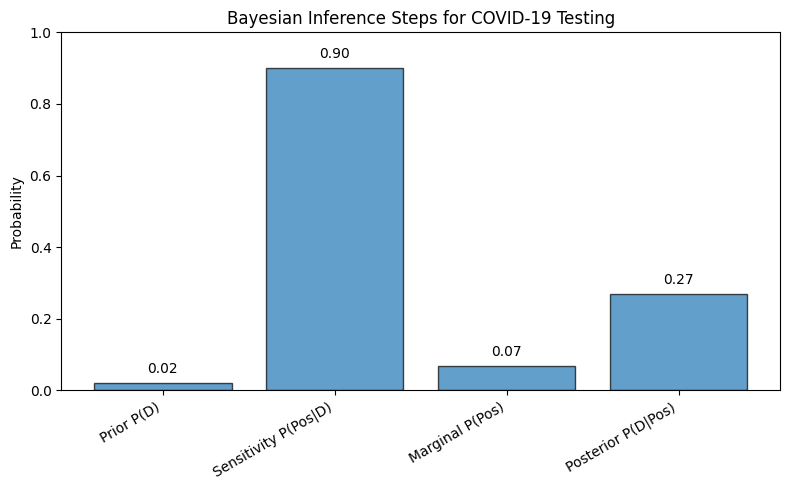

In [6]:
import matplotlib.pyplot as plt

# Prepare data for plotting
labels = ['Prior P(D)', 'Sensitivity P(Pos|D)', 'Marginal P(Pos)', 'Posterior P(D|Pos)']
values = [P_D, sens, P_Pos, P_D_given_Pos]

# Create bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, edgecolor='k', alpha=0.7)
plt.ylim(0, 1)
plt.ylabel('Probability')
plt.title('Bayesian Inference Steps for COVID-19 Testing')

# Annotate bars with values
for bar, val in zip(bars, values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02,
             f'{val:.2f}', ha='center', va='bottom')

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()